# PyDMD: Time Delays

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [668]:
from ast import literal_eval

import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing.hankel import hankel_preprocessing
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD, BOPDMD
from safetensors.torch import load_file
from torch.nn import functional as F

from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.utils import safetensors_metadata_parser

In [669]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [670]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])
NUM_ITERATIONS = literal_eval(metadata["NUM_ITERATIONS"])

data = load_file(file_path)

#### Update dataset

DMD Control panel

In [671]:
NUM_TRAJECTORIES = 2
NUM_STATES = 6
NUM_DELAYS = 8
RANK = 40

In [672]:
x = np.arange(0, 6, 1)
t = np.arange(0, NUM_ITERATIONS, 1)
dt = t[1] - t[0]
delay_t = t[: -NUM_DELAYS + 1]

#### Learn Koopman Operator

In [673]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
)
test_states = reshape_append_time(data["test_states"][:NUM_ITERATIONS, :, :NUM_STATES])

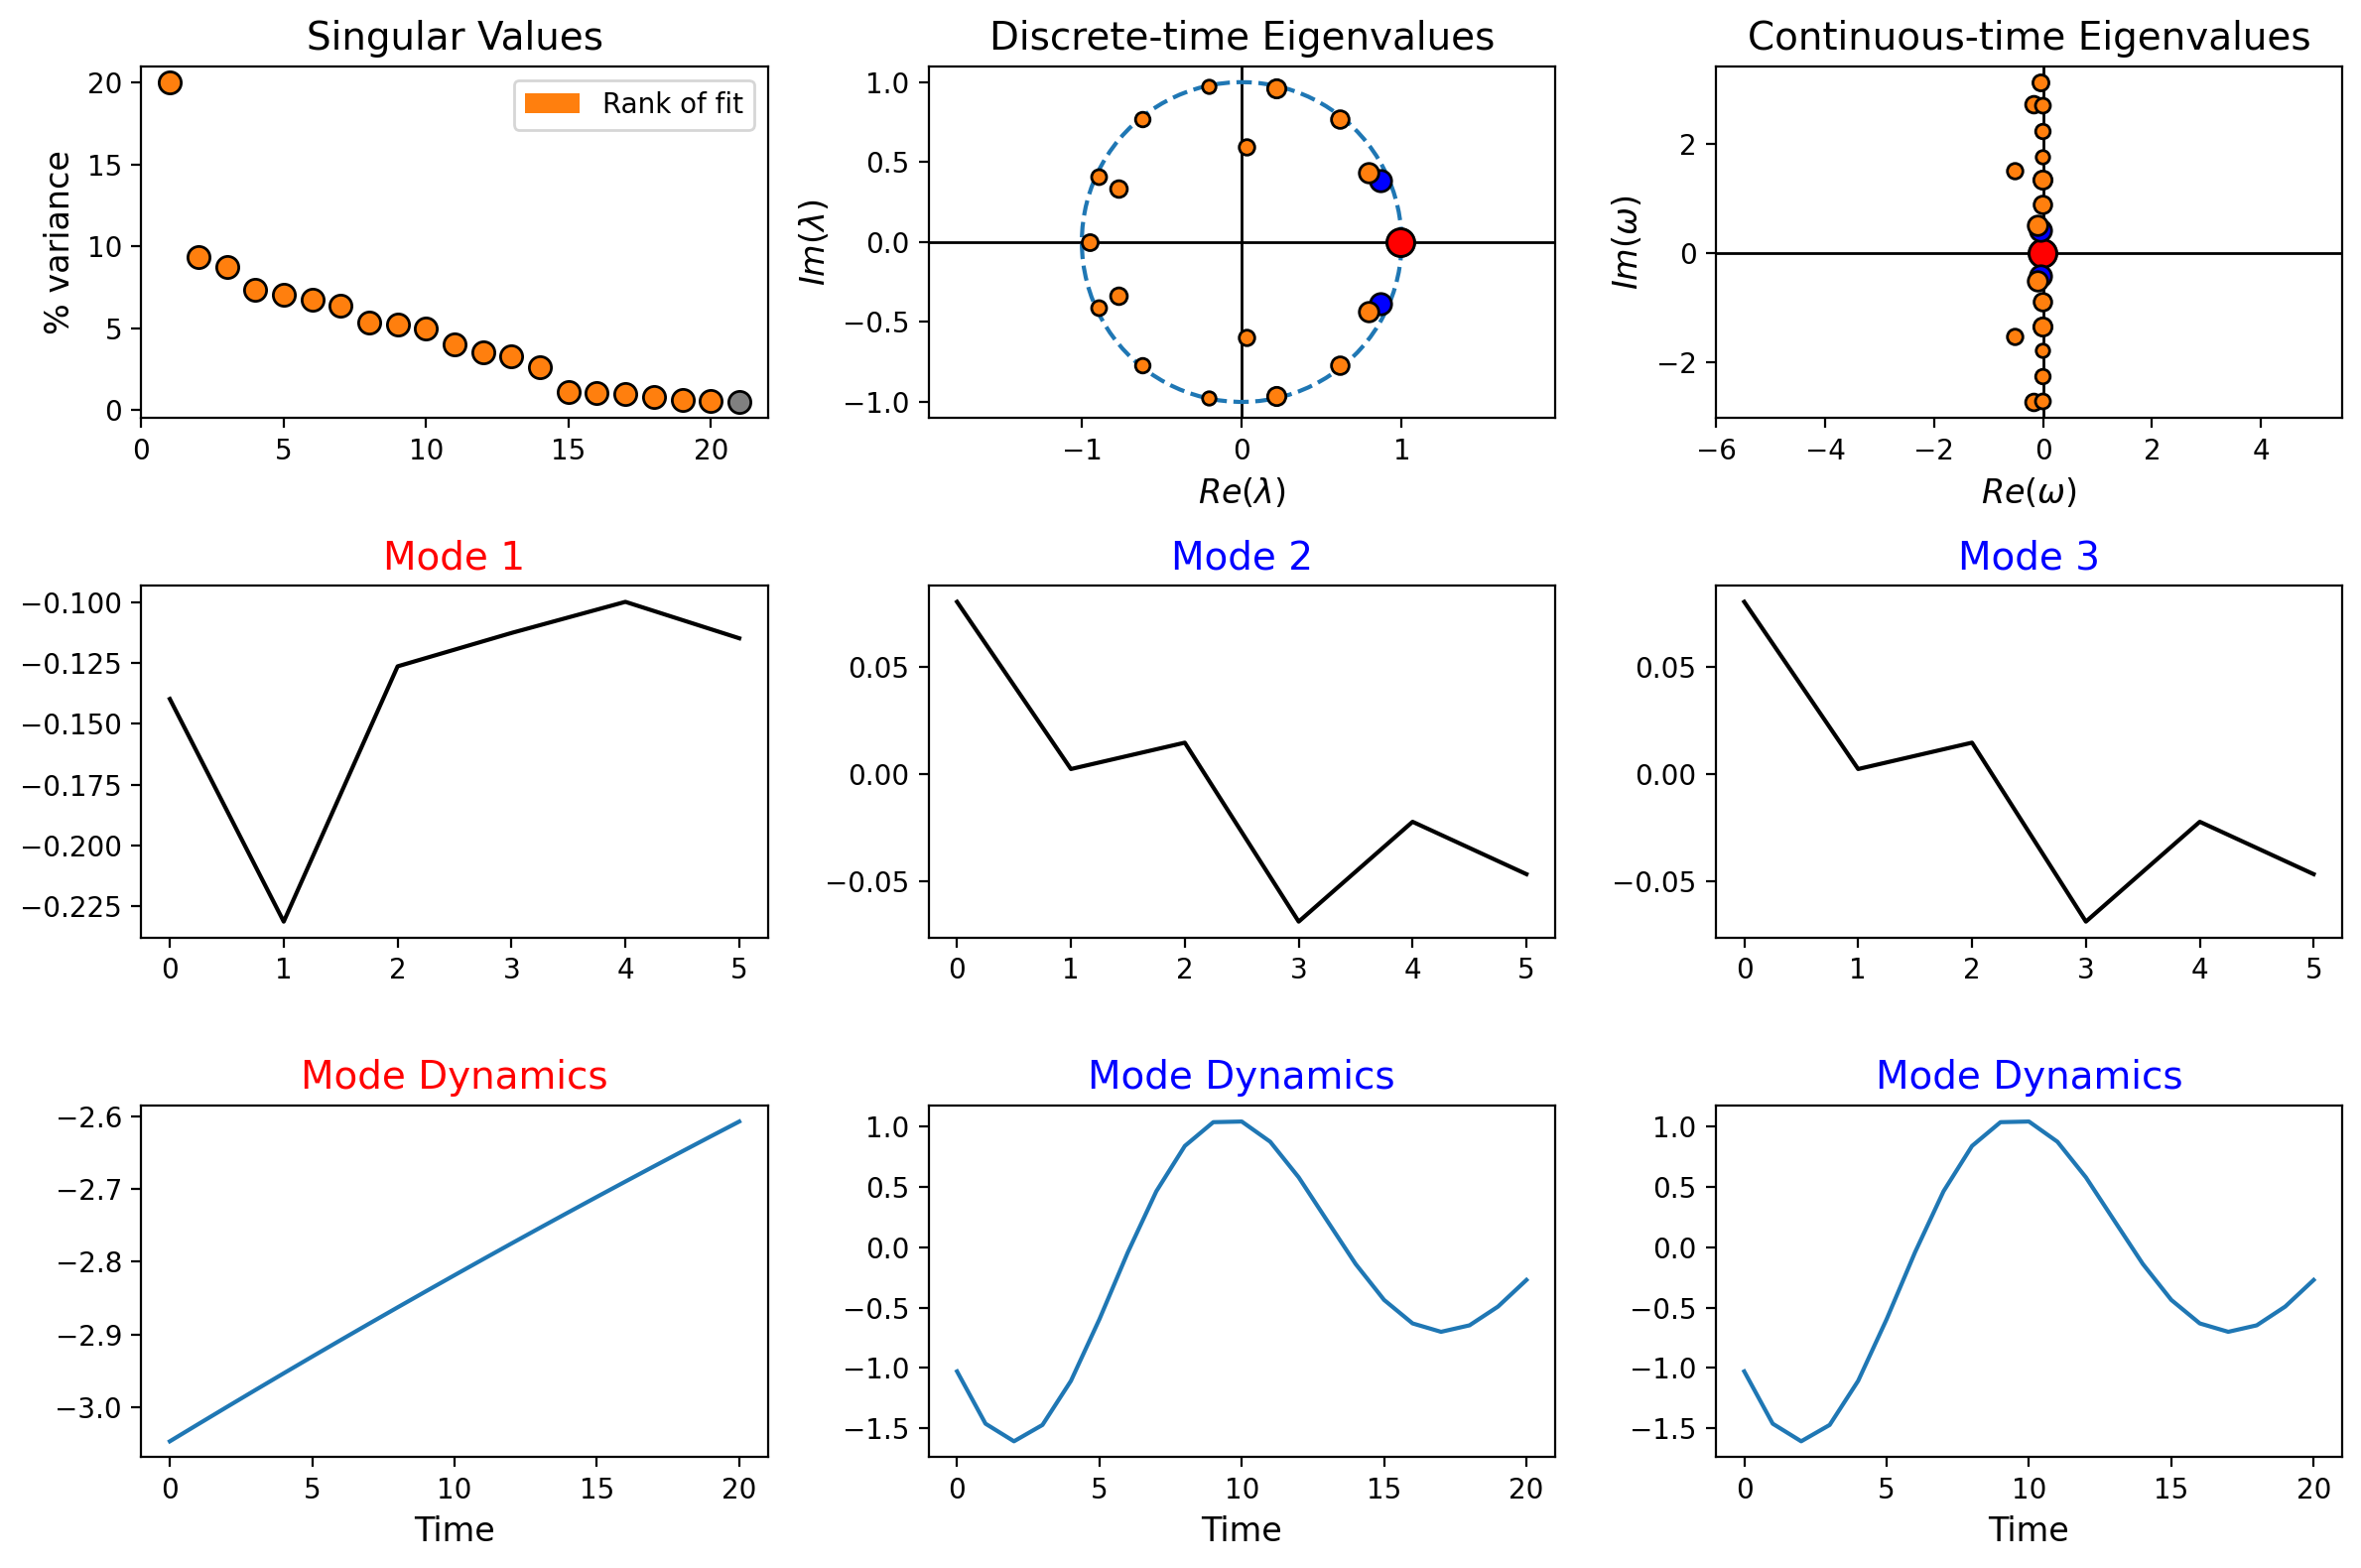

In [674]:
dmd = DMD(svd_rank=RANK)
delay_dmd = hankel_preprocessing(dmd, d=NUM_DELAYS)
delay_dmd.fit(train_states.numpy())
plot_summary(delay_dmd, x=x, d=NUM_DELAYS)

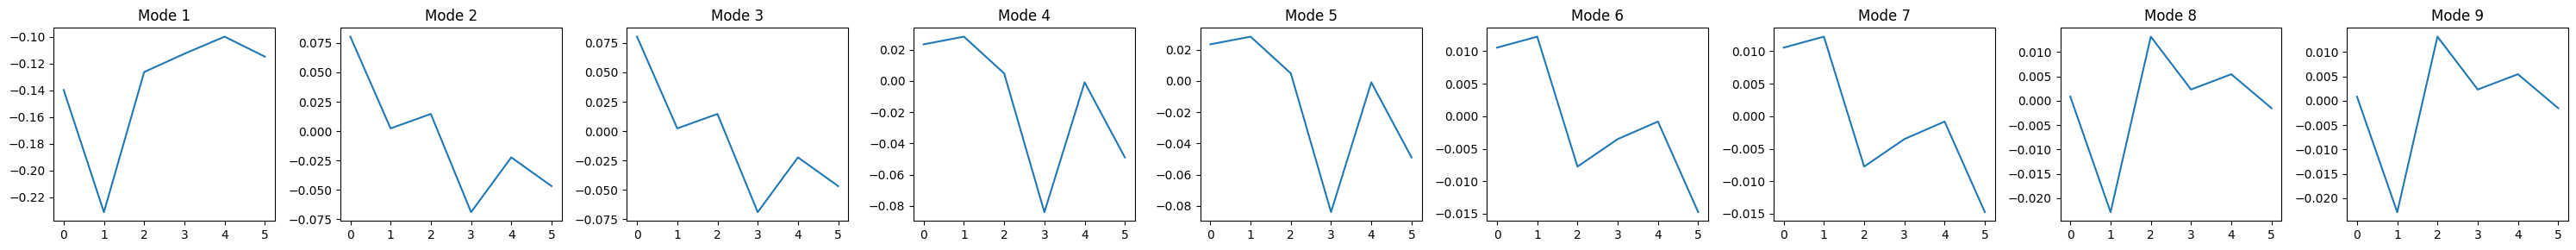

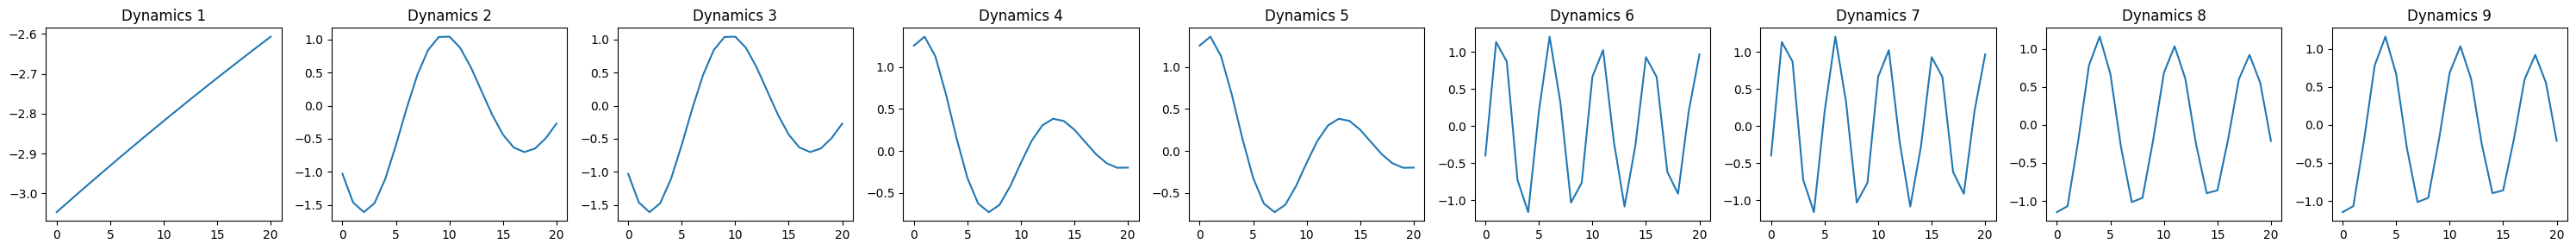

Computed amplitudes (sorted): [-3.047-0.j    -1.028+1.49j  -1.028-1.49j   1.254-0.846j  1.254+0.846j
 -0.394-1.272j -0.394+1.272j -1.148+0.473j -1.148-0.473j]



In [675]:
# Number of modes to plot
num_modes = 9

# Sort indices based on amplitudes in descending order
sorted_indices = np.argsort(-np.abs(delay_dmd.amplitudes))[:num_modes]

# Plotting the modes individually...
plt.figure(figsize=(30, 3))
for i, idx in enumerate(sorted_indices):
    mode = delay_dmd.modes.T[idx, :]
    # Get the average across delays, since we used time-delay.
    mode = np.average(mode.reshape(NUM_DELAYS, len(mode) // NUM_DELAYS), axis=0)
    plt.subplot(1, num_modes, i + 1)
    plt.plot(mode.real, c="tab:blue")
    plt.title(f"Mode {i + 1}")
plt.tight_layout()
plt.show()

# Plotting the dynamics individually...
plt.figure(figsize=(30, 3))
for i, idx in enumerate(sorted_indices):
    dynamic = delay_dmd.dynamics[idx, :]
    plt.subplot(1, num_modes, i + 1)
    plt.plot(dynamic.real, c="tab:blue")
    plt.title(f"Dynamics {i + 1}")
plt.tight_layout()
plt.show()

# # Plot the eigenvalues.
# plot_eigs(delay_dmd, show_axes=True, show_unit_circle=False, figsize=(4, 4))

# Print the amplitudes in descending order.
sorted_amplitudes = delay_dmd.amplitudes[sorted_indices]
print(f"Computed amplitudes (sorted): {np.round(sorted_amplitudes, decimals=3)}\n")

In [676]:
def predict_plot(states, reconstructed, sample, plot=True):
    if plot:
        fig, axs = plt.subplots(
            NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(12, 6)
        )
        for state_idx in range(0, NUM_STATES):
            axs[state_idx].plot(
                t,
                states[
                    state_idx,
                    sample * NUM_ITERATIONS : sample * NUM_ITERATIONS + NUM_ITERATIONS,
                ],
                "-b",
                label="True States",
            )
            axs[state_idx].plot(
                t,
                reconstructed[
                    state_idx,
                    sample * NUM_ITERATIONS : sample * NUM_ITERATIONS + NUM_ITERATIONS,
                ],
                "--r",
                label="Hankel DMD",
            )
            axs[state_idx].set(ylabel=f"state {state_idx}")

        for i in range(0, NUM_STATES):
            axs[i].axvline(x=t[NUM_DELAYS])

    return

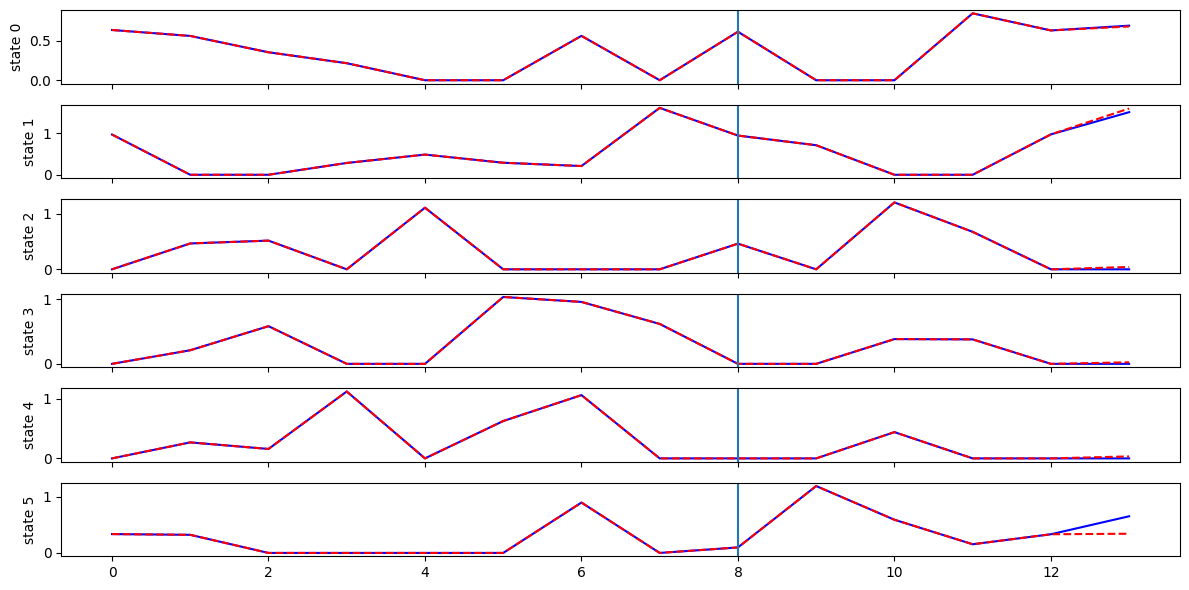

In [682]:
_ = predict_plot(train_states, delay_dmd.reconstructed_data.real, sample=1)